# Etapa 1. Exploración, preparación y fuga de información

En este cuaderno se revisa el conjunto de datos y se prepara una comparación inicial de modelos. Primero se identifican problemas de calidad que no aparecen como celdas vacías. Después se muestra por qué una evaluación puede parecer excelente cuando se filtra información de la respuesta hacia los predictores.

La pregunta de trabajo es: **¿qué tan bien se puede distinguir, con estas variables clínicas, entre los registros con respuesta 0 y respuesta 1?**

## Descripción de los datos

Se utiliza el archivo `heart.csv` del [Heart Failure Prediction Dataset de Kaggle](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction). Cada fila representa un registro y `HeartDisease` es la respuesta que se desea predecir. En el conjunto, el valor 1 indica presencia de enfermedad y el valor 0 indica ausencia.

Las variables predictoras combinan mediciones numéricas y categorías. La preparación debe conservar esa diferencia: las categorías se codifican y las variables numéricas se escalan.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "data/raw/heart.csv").is_file():
    ROOT = ROOT.parent
DATA_PATH = ROOT / "data/raw/heart.csv"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", palette="deep")
df = pd.read_csv(DATA_PATH)
print(f"Archivo leído: {DATA_PATH.name}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
display(df.head())

Archivo leído: heart.csv
Filas: 918 | Columnas: 12


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## ¿Qué contiene cada variable?

La tabla separa las variables numéricas de las categorías. `FastingBS` se almacena como número, aunque representa una condición binaria. `HeartDisease` se reserva como respuesta y no se entrega al modelo como predictor.

In [2]:
diccionario = pd.DataFrame([
    ("Age", "Edad en años", "Numérica"),
    ("Sex", "Sexo registrado (M/F)", "Categórica"),
    ("ChestPainType", "Tipo de dolor torácico", "Categórica"),
    ("RestingBP", "Presión arterial en reposo", "Numérica"),
    ("Cholesterol", "Colesterol sérico", "Numérica"),
    ("FastingBS", "Glucosa en ayunas por encima del umbral indicado", "Binaria"),
    ("RestingECG", "Resultado del electrocardiograma en reposo", "Categórica"),
    ("MaxHR", "Frecuencia cardíaca máxima alcanzada", "Numérica"),
    ("ExerciseAngina", "Angina inducida por ejercicio (Y/N)", "Categórica"),
    ("Oldpeak", "Depresión ST asociada al ejercicio", "Numérica"),
    ("ST_Slope", "Pendiente del segmento ST durante el ejercicio", "Categórica"),
    ("HeartDisease", "Respuesta: 1 indica enfermedad; 0 indica ausencia", "Objetivo"),
], columns=["Variable", "Descripción", "Tipo"])
display(diccionario)

,Variable,Descripción,Tipo
0,Age,Edad en años,Numérica
1,Sex,Sexo registrado (M/F),Categórica
2,ChestPainType,Tipo de dolor torácico,Categórica
3,RestingBP,Presión arterial en reposo,Numérica
4,Cholesterol,Colesterol sérico,Numérica
5,FastingBS,Glucosa en ayunas por encima del umbral indicado,Binaria
6,RestingECG,Resultado del electrocardiograma en reposo,Categórica
7,MaxHR,Frecuencia cardíaca máxima alcanzada,Numérica
8,ExerciseAngina,Angina inducida por ejercicio (Y/N),Categórica
9,Oldpeak,Depresión ST asociada al ejercicio,Numérica


## Revisión inicial de calidad

Antes del modelado se revisan tipos, valores vacíos y registros repetidos. También se cuentan algunos ceros que requieren atención: aunque el archivo no los marca como vacíos, una presión arterial o un nivel de colesterol iguales a cero no son mediciones clínicas válidas.

,Tipo de dato,Valores vacíos,Valores distintos
Age,int64,0,50
Sex,str,0,2
ChestPainType,str,0,4
RestingBP,int64,0,67
Cholesterol,int64,0,222
FastingBS,int64,0,2
RestingECG,str,0,3
MaxHR,int64,0,119
ExerciseAngina,str,0,2
Oldpeak,float64,0,53


Filas duplicadas: 0


,Registros,Porcentaje
HeartDisease,,
0,410,44.7
1,508,55.3


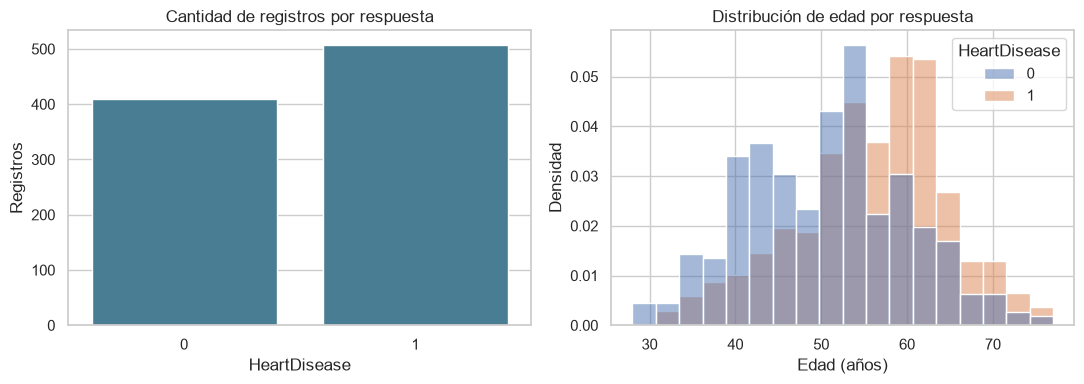

In [3]:
resumen_calidad = pd.DataFrame({
    "Tipo de dato": df.dtypes.astype(str),
    "Valores vacíos": df.isna().sum(),
    "Valores distintos": df.nunique(dropna=False),
})
display(resumen_calidad)
print(f"Filas duplicadas: {df.duplicated().sum()}")

conteo_clases = df["HeartDisease"].value_counts().sort_index()
porcentaje_clases = (conteo_clases / len(df) * 100).round(1)
tabla_clases = pd.DataFrame({"Registros": conteo_clases, "Porcentaje": porcentaje_clases})
tabla_clases.index.name = "HeartDisease"
display(tabla_clases)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="HeartDisease", color="#3B82A0", ax=axes[0])
axes[0].set(title="Cantidad de registros por respuesta", xlabel="HeartDisease", ylabel="Registros")
sns.histplot(data=df, x="Age", hue="HeartDisease", bins=18, stat="density", common_norm=False, ax=axes[1])
axes[1].set(title="Distribución de edad por respuesta", xlabel="Edad (años)", ylabel="Densidad")
plt.tight_layout()

La muestra tiene 918 registros y las dos clases aparecen con frecuencias parecidas: 410 corresponden a 0 y 508 a 1. Esto evita que la evaluación dependa casi por completo de una sola clase, aunque no elimina la necesidad de mirar más de una métrica.

En `Cholesterol` se observan 172 ceros y en `RestingBP` aparece uno. Para el modelado se tomarán como mediciones faltantes y se reemplazarán por la mediana aprendida en los datos de entrenamiento. Esta decisión queda explícita porque el archivo no documenta el significado de esos ceros. La falta de una medición también se conservará como indicador dentro del preprocesamiento.

In [4]:
columnas_cero = ["RestingBP", "Cholesterol"]
filas_cero = []
for columna in columnas_cero:
    if columna in df:
        for clase in sorted(df["HeartDisease"].unique()):
            grupo = df.loc[df["HeartDisease"] == clase, columna]
            cantidad = int((grupo == 0).sum())
            filas_cero.append({
                "Variable": columna,
                "HeartDisease": int(clase),
                "Registros con cero": cantidad,
                "Porcentaje dentro de la clase": 100 * cantidad / len(grupo),
            })
display(pd.DataFrame(filas_cero).round(1))

,Variable,HeartDisease,Registros con cero,Porcentaje dentro de la clase
0,RestingBP,0,0,0.0
1,RestingBP,1,1,0.2
2,Cholesterol,0,20,4.9
3,Cholesterol,1,152,29.9


El porcentaje de ceros en colesterol es distinto entre las dos clases. Esto no prueba que la ausencia de la medición cause la enfermedad. Sí muestra que el patrón de captura de los datos puede estar relacionado con la respuesta, por lo que se conserva como una limitación a tener en cuenta al interpretar el modelo.

## Demostración de fuga de información

La fuga ocurre cuando durante el entrenamiento se usa información que no estaría disponible al momento de predecir un caso nuevo. Para ilustrarlo, se crea deliberadamente una variable artificial que se construye usando la respuesta. Esa variable no se usa en el flujo correcto.

También se compara el ajuste del preprocesamiento antes y después de la separación de los datos. En el procedimiento correcto, la división se hace primero y cada transformación se aprende dentro de un `Pipeline`, solo con los datos que participan en el entrenamiento de cada partición.

In [5]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from app.modeling import build_preprocessor, prepare_features_and_target

X, y = prepare_features_and_target(df)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
parametros_svc = {"C": [0.1, 1, 10], "gamma": ["scale", 0.1]}

# Flujo deliberadamente incorrecto: la variable artificial incorpora la respuesta.
rng = np.random.default_rng(42)
X_con_fuga = X.copy()
X_con_fuga["variable_con_fuga"] = y.to_numpy() + rng.normal(0, 0.03, len(y))

# El preprocesamiento también se ajusta con toda la base antes de separar.
preprocesador_incorrecto = build_preprocessor(X_con_fuga)
X_transformada_incorrecta = preprocesador_incorrecto.fit_transform(X_con_fuga)
X_train_mal, X_test_mal, y_train_mal, y_test_mal = train_test_split(
    X_transformada_incorrecta, y, test_size=0.20, random_state=42, stratify=y
)
busqueda_mal = GridSearchCV(
    SVC(), parametros_svc, scoring="roc_auc", cv=cv, refit=True, n_jobs=1
)
busqueda_mal.fit(X_train_mal, y_train_mal)
auc_con_fuga = roc_auc_score(
    y_test_mal, busqueda_mal.best_estimator_.decision_function(X_test_mal)
)

# Flujo correcto: se separa primero y el preprocesamiento queda dentro del Pipeline.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
flujo_correcto = Pipeline([
    ("preprocesamiento", build_preprocessor(X_train)),
    ("clasificador", SVC()),
])
busqueda_correcta = GridSearchCV(
    flujo_correcto,
    {f"clasificador__{k}": v for k, v in parametros_svc.items()},
    scoring="roc_auc",
    cv=cv,
    refit=True,
    n_jobs=1,
)
busqueda_correcta.fit(X_train, y_train)
auc_sin_fuga = roc_auc_score(
    y_test, busqueda_correcta.best_estimator_.decision_function(X_test)
)

comparacion_fuga = pd.DataFrame({
    "Procedimiento": ["Con fuga intencional", "Flujo correcto"],
    "AUC en prueba": [auc_con_fuga, auc_sin_fuga],
})
display(comparacion_fuga.round(3))

,Procedimiento,AUC en prueba
0,Con fuga intencional,1.00
1,Flujo correcto,0.95


El AUC de la primera fila no es una medida válida del desempeño futuro: la variable artificial le entrega al modelo una pista construida directamente con la respuesta. Un valor cercano a 1 en ese escenario refleja el error del procedimiento, no una capacidad real de predicción. El flujo correcto usa solo las variables disponibles y reserva el conjunto de prueba hasta la evaluación.

## Comparación de clasificadores

Se comparan cinco alternativas: SVC, regresión logística, bosque aleatorio, K vecinos y Gradient Boosting. Cada una se ajusta con `GridSearchCV` y validación cruzada de cinco particiones. En cada partición, la imputación, la codificación y el escalamiento se vuelven a aprender solo con los datos de entrenamiento.

El ranking se ordena por AUC promedio de validación cruzada. El conjunto de prueba se usa para revisar el resultado final y no para escoger los hiperparámetros.

In [6]:
from app.modeling import compare_models

resultados_modelos, busquedas_modelos = compare_models(
    X_train, y_train, X_test, y_test, n_splits=5, n_jobs=1
)
columnas_resultado = [
    "Posición", "Modelo", "AUC promedio CV", "AUC prueba", "Exactitud prueba"
]
display(resultados_modelos[columnas_resultado].round(3))

,Posición,Modelo,AUC promedio CV,AUC prueba,Exactitud prueba
0,1,Bosque aleatorio,0.933,0.937,0.886
1,2,Gradient Boosting,0.930,0.931,0.908
2,3,Regresión logística,0.928,0.932,0.891
3,4,SVC,0.925,0.944,0.880
4,5,K vecinos (KNN),0.920,0.947,0.897


In [7]:
mejor_cv = resultados_modelos.iloc[0]
mejor_auc_prueba = resultados_modelos.loc[resultados_modelos["AUC prueba"].idxmax()]
mejor_exactitud = resultados_modelos.loc[resultados_modelos["Exactitud prueba"].idxmax()]
print(
    f"Según el AUC promedio de validación cruzada, el primer candidato es "
    f"{mejor_cv['Modelo']} ({mejor_cv['AUC promedio CV']:.3f})."
)
print(
    f"En esta partición de prueba, el AUC más alto corresponde a "
    f"{mejor_auc_prueba['Modelo']} ({mejor_auc_prueba['AUC prueba']:.3f}), "
    f"y la exactitud más alta a {mejor_exactitud['Modelo']} "
    f"({mejor_exactitud['Exactitud prueba']:.3f})."
)

Según el AUC promedio de validación cruzada, el primer candidato es Bosque aleatorio (0.933).
En esta partición de prueba, el AUC más alto corresponde a K vecinos (KNN) (0.947), y la exactitud más alta a Gradient Boosting (0.908).


Las métricas no ordenan necesariamente los modelos igual. El AUC evalúa qué tan bien se ordenan los casos con y sin enfermedad a través de distintos puntos de corte. La exactitud cuenta qué proporción quedó clasificada correctamente usando el umbral habitual de 0,5. Por eso se reportan ambas y se toma la validación cruzada como criterio inicial de selección, sin presentar diferencias pequeñas como una superioridad definitiva.